In [2]:
import numpy as np
import pickle
import pandas as pd
from preprocessor_loan import *  # this is for loading the .py file which contains all the libraries and the custom functions.
from imblearn.over_sampling import SMOTE

In [3]:
dff=pd.read_csv("C:/Users/Tanmay Patel/Desktop/CDS/CDS/Feature Engineering/loan.csv")
dff

,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,...,Marital Status,Education Level,Employment Type,Property Value,Collateral,Bankruptcy History,Housing Type,Years in Current Job,Savings Amount,Risk Score
0,65087372,10000,32236,12329.36286,59,BAT2522922,11.135007,B,C4,MORTGAGE,...,Divorced,Master's,Unemployed,52764,No,0,Owned,33,190445,0.216437
1,1450153,3609,11940,12191.99692,59,BAT1586599,12.237563,C,D3,RENT,...,Single,Bachelor's,Salaried,500995,No,1,Owned,33,131852,0.677130
2,1969101,28276,9311,21603.22455,59,BAT2136391,12.545884,F,D4,MORTGAGE,...,Divorced,Bachelor's,Unemployed,291172,Yes,1,Rented,35,174644,0.981313
3,6651430,11170,6954,17877.15585,59,BAT2428731,16.731201,C,C3,MORTGAGE,...,Single,Master's,Salaried,933714,No,0,Mortgaged,33,61604,0.399829
4,14354669,16890,13226,13539.92667,59,BAT5341619,15.008300,C,D4,MORTGAGE,...,Divorced,PhD,Unemployed,353721,No,0,Owned,22,94529,0.492224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67458,16164945,13601,6848,13175.28583,59,BAT3193689,9.408858,C,A4,MORTGAGE,...,Single,Master's,Self-Employed,814874,No,0,Owned,31,24996,0.646428
67459,35182714,8323,11046,15637.46301,59,BAT1780517,9.972104,C,B3,RENT,...,Divorced,Bachelor's,Self-Employed,61136,Yes,1,Owned,33,196210,0.066679
67460,16435904,15897,32921,12329.45775,59,BAT1761981,19.650943,A,F3,MORTGAGE,...,Widowed,Master's,Salaried,190451,Yes,1,Rented,30,136420,0.916311
67461,5300325,16567,4975,21353.68465,59,BAT2333412,13.169095,D,E3,OWN,...,Single,PhD,Salaried,553361,No,0,Mortgaged,30,52979,0.681814


In [4]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67463 entries, 0 to 67462
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            67463 non-null  int64  
 1   Loan Amount                   67463 non-null  int64  
 2   Funded Amount                 67463 non-null  int64  
 3   Funded Amount Investor        67463 non-null  float64
 4   Term                          67463 non-null  int64  
 5   Batch Enrolled                67463 non-null  object 
 6   Interest Rate                 67463 non-null  float64
 7   Grade                         67463 non-null  object 
 8   Sub Grade                     67463 non-null  object 
 9   Employment Duration           67463 non-null  object 
 10  Home Ownership                67463 non-null  float64
 11  Verification Status           67463 non-null  object 
 12  Payment Plan                  67463 non-null  object 
 13  L

In [5]:
file=open("cust_lone.pkl","rb")
pre=pickle.load(file)
pre

ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                 ['Employment Duration', 'Loan Purpose',
                                  'Marital Status', 'Education Level',
                                  'Employment Type', 'Housing Type']),
                                ('minmax', MinMaxScaler(),
                                 ['Loan Amount', 'Funded Amount',
                                  'Funded Amount Investor', 'Interest Rate',
                                  'Home Ownership', 'Debit to Income',
                                  'Open Account', 'Revolving Balance',
                                  'Revolving Utilities', 'Total Accounts'...
                                ('custom',
                                 FunctionTransformer(func=<function divide at 0x0000020C99169620>),
                                 ['Loan Tenure']),
                                ('Label_encoder1', ModifiedLabelEncoder(),
                                 ['Verification Status']),
                                ('Label_encoder2', ModifiedLabelEncoder(),
                                 ['Income Stability']),
                                ('Label_encoder', ModifiedLabelEncoder(),
                                 ['Collateral']),
                                ('ordinal',
                                 OrdinalEncoder(categories=[['G', 'F', 'E', 'D',
                                                             'C', 'B', 'A']]),
                                 ['Grade'])])

In [6]:
processed_data=pre.fit_transform(dff)
processed_data

C:\Users\Tanmay Patel\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Tanmay Patel\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Tanmay Patel\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([[1., 0., 0., ..., 1., 0., 5.],
       [0., 0., 1., ..., 0., 0., 4.],
       [1., 0., 0., ..., 1., 1., 1.],
       ...,
       [1., 0., 0., ..., 0., 1., 6.],
       [0., 1., 0., ..., 0., 0., 3.],
       [1., 0., 0., ..., 0., 1., 5.]])

In [7]:
def get_ct_feature_names(ct):
    output_features = []

    for name, transformer, cols in ct.transformers_:
        if name == 'remainder':
            continue

        # If transformer is Pipeline
        if hasattr(transformer, 'named_steps'):
            transformer = list(transformer.named_steps.values())[-1]

        # OneHotEncoder
        if hasattr(transformer, 'get_feature_names_out'):
            output_features.extend(transformer.get_feature_names_out(cols))
        else:
            output_features.extend(cols)

    return output_features


feature_names = get_ct_feature_names(pre)


In [8]:
import pandas as pd

df_processed = pd.DataFrame(processed_data, columns=feature_names)
df_processed.head()

,Employment Duration_MORTGAGE,Employment Duration_OWN,Employment Duration_RENT,Loan Purpose_Business,Loan Purpose_Car,Loan Purpose_Education,Loan Purpose_Home,Loan Purpose_Personal,Marital Status_Divorced,Marital Status_Married,...,Delinquency - two years,Inquires - six months,Public Record,Loan Status,Bankruptcy History,Loan Tenure,Verification Status,Income Stability,Collateral,Grade
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,5.0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,0.0,0.0,4.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,1.0,1.0,1.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,4.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,3.0,1.0,0.0,0.0,4.0,1.0,1.0,0.0,4.0


In [9]:
pd.set_option('display.max_columns',None)
df_processed

,Employment Duration_MORTGAGE,Employment Duration_OWN,Employment Duration_RENT,Loan Purpose_Business,Loan Purpose_Car,Loan Purpose_Education,Loan Purpose_Home,Loan Purpose_Personal,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Marital Status_Widowed,Education Level_Bachelor's,Education Level_High School,Education Level_Master's,Education Level_PhD,Employment Type_Salaried,Employment Type_Self-Employed,Employment Type_Unemployed,Housing Type_Mortgaged,Housing Type_Owned,Housing Type_Rented,Loan Amount,Funded Amount,Funded Amount Investor,Interest Rate,Home Ownership,Debit to Income,Open Account,Revolving Balance,Revolving Utilities,Total Accounts,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Credit Score,Monthly Expenses,Dependents,Co-Applicant Income,Previous Defaults,Current Liabilities,Loan Tenure,Debt-to-Income Ratio,Debt-to-Income Ratio,Property Value,Years in Current Job,Savings Amount,Risk Score,Delinquency - two years,Inquires - six months,Public Record,Loan Status,Bankruptcy History,Loan Tenure,Verification Status,Income Stability,Collateral,Grade
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.264403,0.918699,0.330964,0.265983,0.412699,0.400709,0.314286,0.207350,0.742775,0.044118,0.204587,0.002395,0.000574,0.004757,0.001827,0.264009,0.028071,0.185792,0.223918,0.00,0.058442,1.0,0.415809,0.25,0.597618,0.597618,0.002876,0.846154,0.952253,0.216434,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,5.0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.076355,0.321495,0.326910,0.316414,0.064442,0.378315,0.285714,0.006944,0.776130,0.132353,0.053721,0.000849,0.000546,0.005843,0.003167,0.154651,0.099341,0.792350,0.347405,0.25,0.025041,0.0,0.563031,0.50,0.287504,0.287504,0.474724,0.846154,0.659275,0.677137,0.0,0.0,0.0,0.0,1.0,3.0,1.0,0.0,0.0,4.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.802154,0.244137,0.604649,0.330517,0.196264,0.704983,0.342857,0.015761,0.020499,0.235294,0.060055,0.440618,0.000991,0.006114,0.002010,0.075786,0.125669,0.491803,0.732709,1.00,0.484079,1.0,0.041965,0.50,0.042703,0.042703,0.253845,0.897436,0.873244,0.981327,0.0,0.0,0.0,0.0,1.0,3.0,1.0,1.0,1.0,1.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.298829,0.174783,0.494688,0.521957,0.239071,0.445864,0.142857,0.118179,0.668777,0.117647,0.019825,0.001035,0.000025,0.004495,0.002375,0.007284,0.295820,0.193078,0.448363,1.00,0.403156,1.0,0.759288,0.00,0.536726,0.536726,0.930242,0.846154,0.308019,0.399830,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,4.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.467134,0.359335,0.366690,0.443150,0.075669,0.424458,0.314286,0.013204,0.845063,0.264706,0.008709,0.453007,0.297354,0.002211,0.026127,0.106571,0.107804,0.129326,0.865460,0.50,0.779391,1.0,0.479575,0.75,0.349974,0.349974,0.319690,0.564103,0.472651,0.492227,1.0,3.0,1.0,0.0,0.0,4.0,1.0,1.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67458,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.370358,0.171664,0.355929,0.187027,0.177015,0.704149,0.314286,0.035165,0.969262,0.220588,0.138089,0.000551,0.129663,0.005186,0.002862,0.153942,0.166364,0.282332,0.114749,0.00,0.365095,1.0,0.014855,0.25,0.320855,0.320855,0.805141,0.794872,0.124971,0.646435,1.0,0.0,0.0,1.0,0.0,2.0,2.0,1.0,0.0,4.0
67459,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.215059,0.295189,0.428591,0.212790,0.129896,0.436893,0.285714,0.083270,0.155495,0.147059,0.216559,0.000636,0.000463,0.00

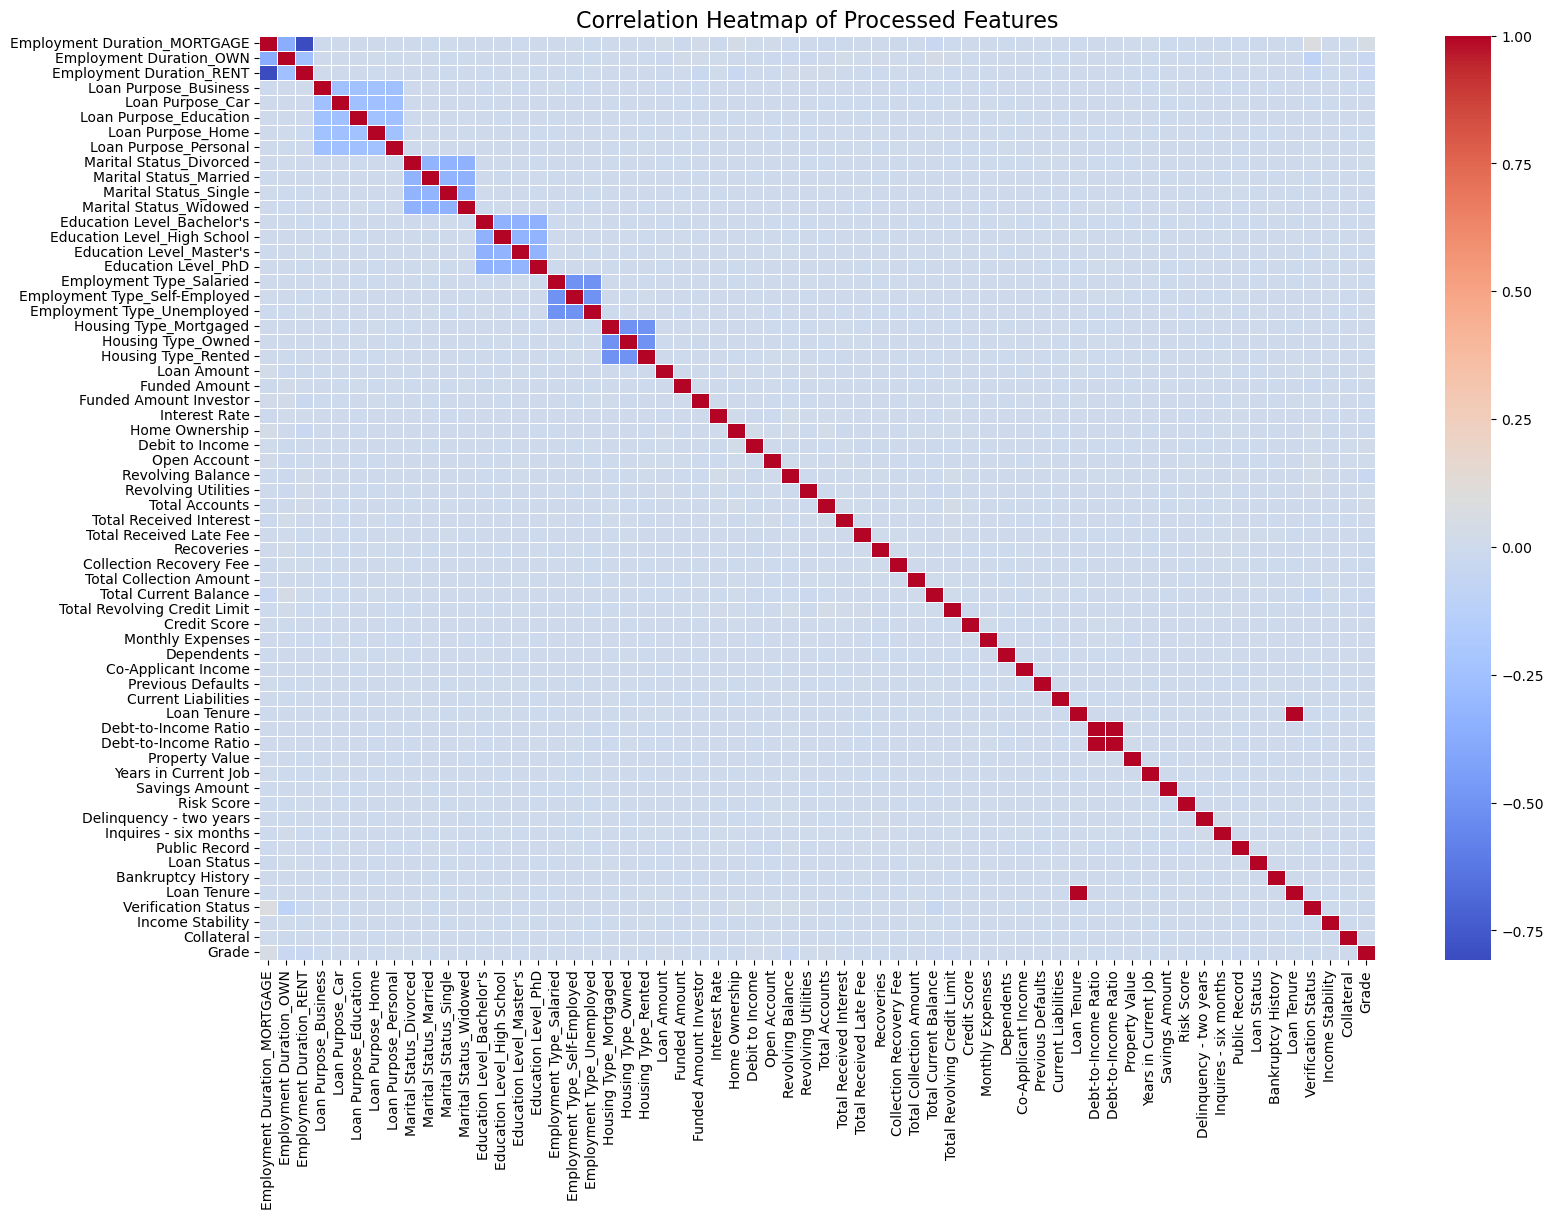

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr = df_processed.corr()

# Set figure size
plt.figure(figsize=(18, 12))

# Draw heatmap
sns.heatmap(corr, 
            annot=False, 
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap of Processed Features", fontsize=16)
plt.show()

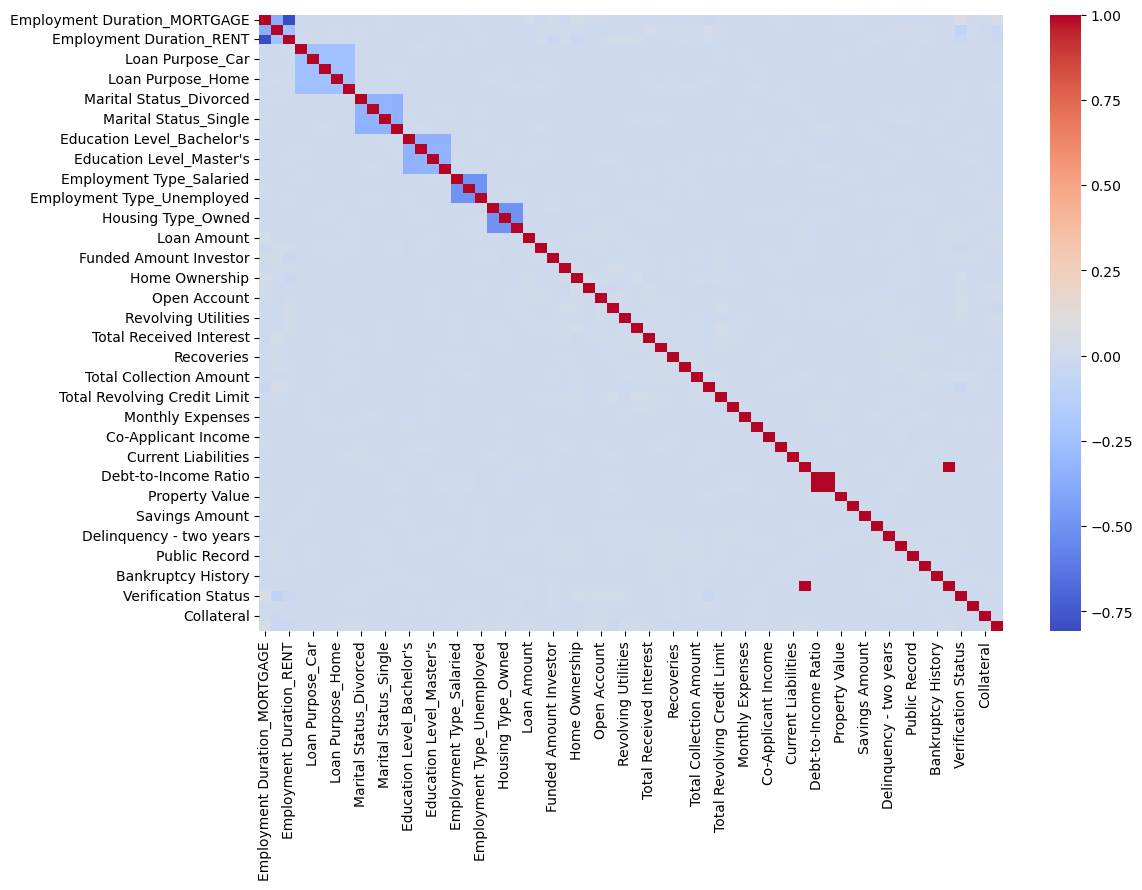

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df_processed.corr(), cmap="coolwarm")
plt.show()

In [12]:
import numpy as np

target = "Loan Status"   # <-- change if needed

corr = df_processed.corr()[target].abs()

high_corr = corr[corr > 0.7]
print(high_corr)

Loan Status    1.0
Name: Loan Status, dtype: float64


In [13]:
outliers = [
    "Funded Amount Investor", "Interest Rate", "Home Ownership",
    "Revolving Balance", "Total Accounts", "Total Received Interest",
    "Total Received Late Fee", "Recoveries", "Collection Recovery Fee",
    "Total Collection Amount", "Total Current Balance",
    "Total Revolving Credit Limit"
]

for col in outliers:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nColumn: {col}")
    print(f"  IQR = {IQR}")
    print(f"  Lower Bound = {lower_bound}")
    print(f"  Upper Bound = {upper_bound}")



Column: Funded Amount Investor
  IQR = 0.23538062161508072
  Lower Bound = -0.09581684978358662
  Upper Bound = 0.8457056366767364

Column: Interest Rate
  IQR = 0.2239643838500103
  Lower Bound = -0.15402913073001887
  Upper Bound = 0.7418284046700223

Column: Home Ownership
  IQR = 0.10952753536928733
  Lower Bound = -0.06960394977293957
  Upper Bound = 0.36850619170420973

Column: Revolving Balance
  IQR = 0.06522966143004968
  Lower Bound = -0.07597726903440431
  Upper Bound = 0.1849413766857944

Column: Total Accounts
  IQR = 0.1470588235294118
  Lower Bound = -0.08823529411764713
  Upper Bound = 0.5

Column: Total Received Interest
  IQR = 0.1459122040992196
  Lower Bound = -0.17926687517528447
  Upper Bound = 0.40438194122159393

Column: Total Received Late Fee
  IQR = 0.001191258578483447
  Lower Bound = -0.0012915484459370369
  Upper Bound = 0.0034734858679967514

Column: Recoveries
  IQR = 0.0008781577496888411
  Lower Bound = -0.0009429584822251996
  Upper Bound = 0.0025696

In [14]:
df_processed.loc[df_processed["Funded Amount Investor"]>0.8457056366767364,"Funded Amount Investor"] = df_processed['Funded Amount Investor'].median()

In [15]:
df_processed.loc[df_processed["Interest Rate"]>0.7418284046700223,"Interest Rate"] = df_processed['Interest Rate'].median()


In [16]:
df_processed.loc[df_processed["Home Ownership"]>0.36850619170420973,"Home Ownership"] = df_processed['Home Ownership'].median()

In [17]:
df_processed.loc[df_processed["Revolving Balance"]>0.1849413766857944,"Revolving Balance"] = df_processed['Revolving Balance'].median()

In [18]:
df_processed.loc[df_processed["Total Accounts"]>0.1849413766857944,"Total Accounts"] = df_processed['Total Accounts'].median()

In [19]:
df_processed.loc[df_processed["Total Received Interest"]>0.404381941221593934,"Total Received Interest"] = df_processed['Total Received Interest'].median()

In [20]:
df_processed.loc[df_processed["Total Received Late Fee"]>0.0034734858679967514,"Total Received Late Fee"] = df_processed['Total Received Late Fee'].median()

In [21]:
df_processed.loc[df_processed["Recoveries"]>0.0025696725165301653,"Recoveries"] = df_processed['Recoveries'].median()

In [22]:
df_processed.loc[df_processed["Collection Recovery Fee"]> 0.011760197538671312,"Collection Recovery Fee"] = df_processed['Collection Recovery Fee'].median()

In [23]:
df_processed.loc[df_processed["Total Collection Amount"]> 0.004750304506699148,"Total Collection Amount"] = df_processed['Total Collection Amount'].median()

In [24]:
df_processed.loc[df_processed["Total Current Balance"]> 0.4204232682837708,"Total Current Balance"] = df_processed['Total Current Balance'].median()

In [25]:
df_processed.loc[df_processed["Total Revolving Credit Limit"]> 0.4204232682837708,"Total Revolving Credit Limit"] = df_processed['Total Revolving Credit Limit'].median()

In [26]:
df_processed


,Employment Duration_MORTGAGE,Employment Duration_OWN,Employment Duration_RENT,Loan Purpose_Business,Loan Purpose_Car,Loan Purpose_Education,Loan Purpose_Home,Loan Purpose_Personal,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Marital Status_Widowed,Education Level_Bachelor's,Education Level_High School,Education Level_Master's,Education Level_PhD,Employment Type_Salaried,Employment Type_Self-Employed,Employment Type_Unemployed,Housing Type_Mortgaged,Housing Type_Owned,Housing Type_Rented,Loan Amount,Funded Amount,Funded Amount Investor,Interest Rate,Home Ownership,Debit to Income,Open Account,Revolving Balance,Revolving Utilities,Total Accounts,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Credit Score,Monthly Expenses,Dependents,Co-Applicant Income,Previous Defaults,Current Liabilities,Loan Tenure,Debt-to-Income Ratio,Debt-to-Income Ratio,Property Value,Years in Current Job,Savings Amount,Risk Score,Delinquency - two years,Inquires - six months,Public Record,Loan Status,Bankruptcy History,Loan Tenure,Verification Status,Income Stability,Collateral,Grade
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.264403,0.918699,0.330964,0.265983,0.139704,0.400709,0.314286,0.047172,0.742775,0.044118,0.204587,0.002395,0.000574,0.004757,0.001827,0.264009,0.028071,0.185792,0.223918,0.00,0.058442,1.0,0.415809,0.25,0.597618,0.597618,0.002876,0.846154,0.952253,0.216434,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,5.0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.076355,0.321495,0.326910,0.316414,0.064442,0.378315,0.285714,0.006944,0.776130,0.132353,0.053721,0.000849,0.000546,0.005843,0.003167,0.154651,0.099341,0.792350,0.347405,0.25,0.025041,0.0,0.563031,0.50,0.287504,0.287504,0.474724,0.846154,0.659275,0.677137,0.0,0.0,0.0,0.0,1.0,3.0,1.0,0.0,0.0,4.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.802154,0.244137,0.604649,0.330517,0.196264,0.704983,0.342857,0.015761,0.020499,0.205882,0.060055,0.001018,0.000991,0.006114,0.002010,0.075786,0.125669,0.491803,0.732709,1.00,0.484079,1.0,0.041965,0.50,0.042703,0.042703,0.253845,0.897436,0.873244,0.981327,0.0,0.0,0.0,0.0,1.0,3.0,1.0,1.0,1.0,1.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.298829,0.174783,0.494688,0.521957,0.239071,0.445864,0.142857,0.118179,0.668777,0.117647,0.019825,0.001035,0.000025,0.004495,0.002375,0.007284,0.295820,0.193078,0.448363,1.00,0.403156,1.0,0.759288,0.00,0.536726,0.536726,0.930242,0.846154,0.308019,0.399830,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,4.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.467134,0.359335,0.366690,0.443150,0.075669,0.424458,0.314286,0.013204,0.845063,0.205882,0.008709,0.001018,0.000768,0.002211,0.002132,0.106571,0.107804,0.129326,0.865460,0.50,0.779391,1.0,0.479575,0.75,0.349974,0.349974,0.319690,0.564103,0.472651,0.492227,1.0,3.0,1.0,0.0,0.0,4.0,1.0,1.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67458,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.370358,0.171664,0.355929,0.187027,0.177015,0.704149,0.314286,0.035165,0.969262,0.205882,0.138089,0.000551,0.000768,0.005186,0.002862,0.153942,0.166364,0.282332,0.114749,0.00,0.365095,1.0,0.014855,0.25,0.320855,0.320855,0.805141,0.794872,0.124971,0.646435,1.0,0.0,0.0,1.0,0.0,2.0,2.0,1.0,0.0,4.0
67459,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.215059,0.295189,0.428591,0.212790,0.129896,0.436893,0.285714,0.083270,0.155495,0.147059,0.216559,0.000636,0.000463,0.00

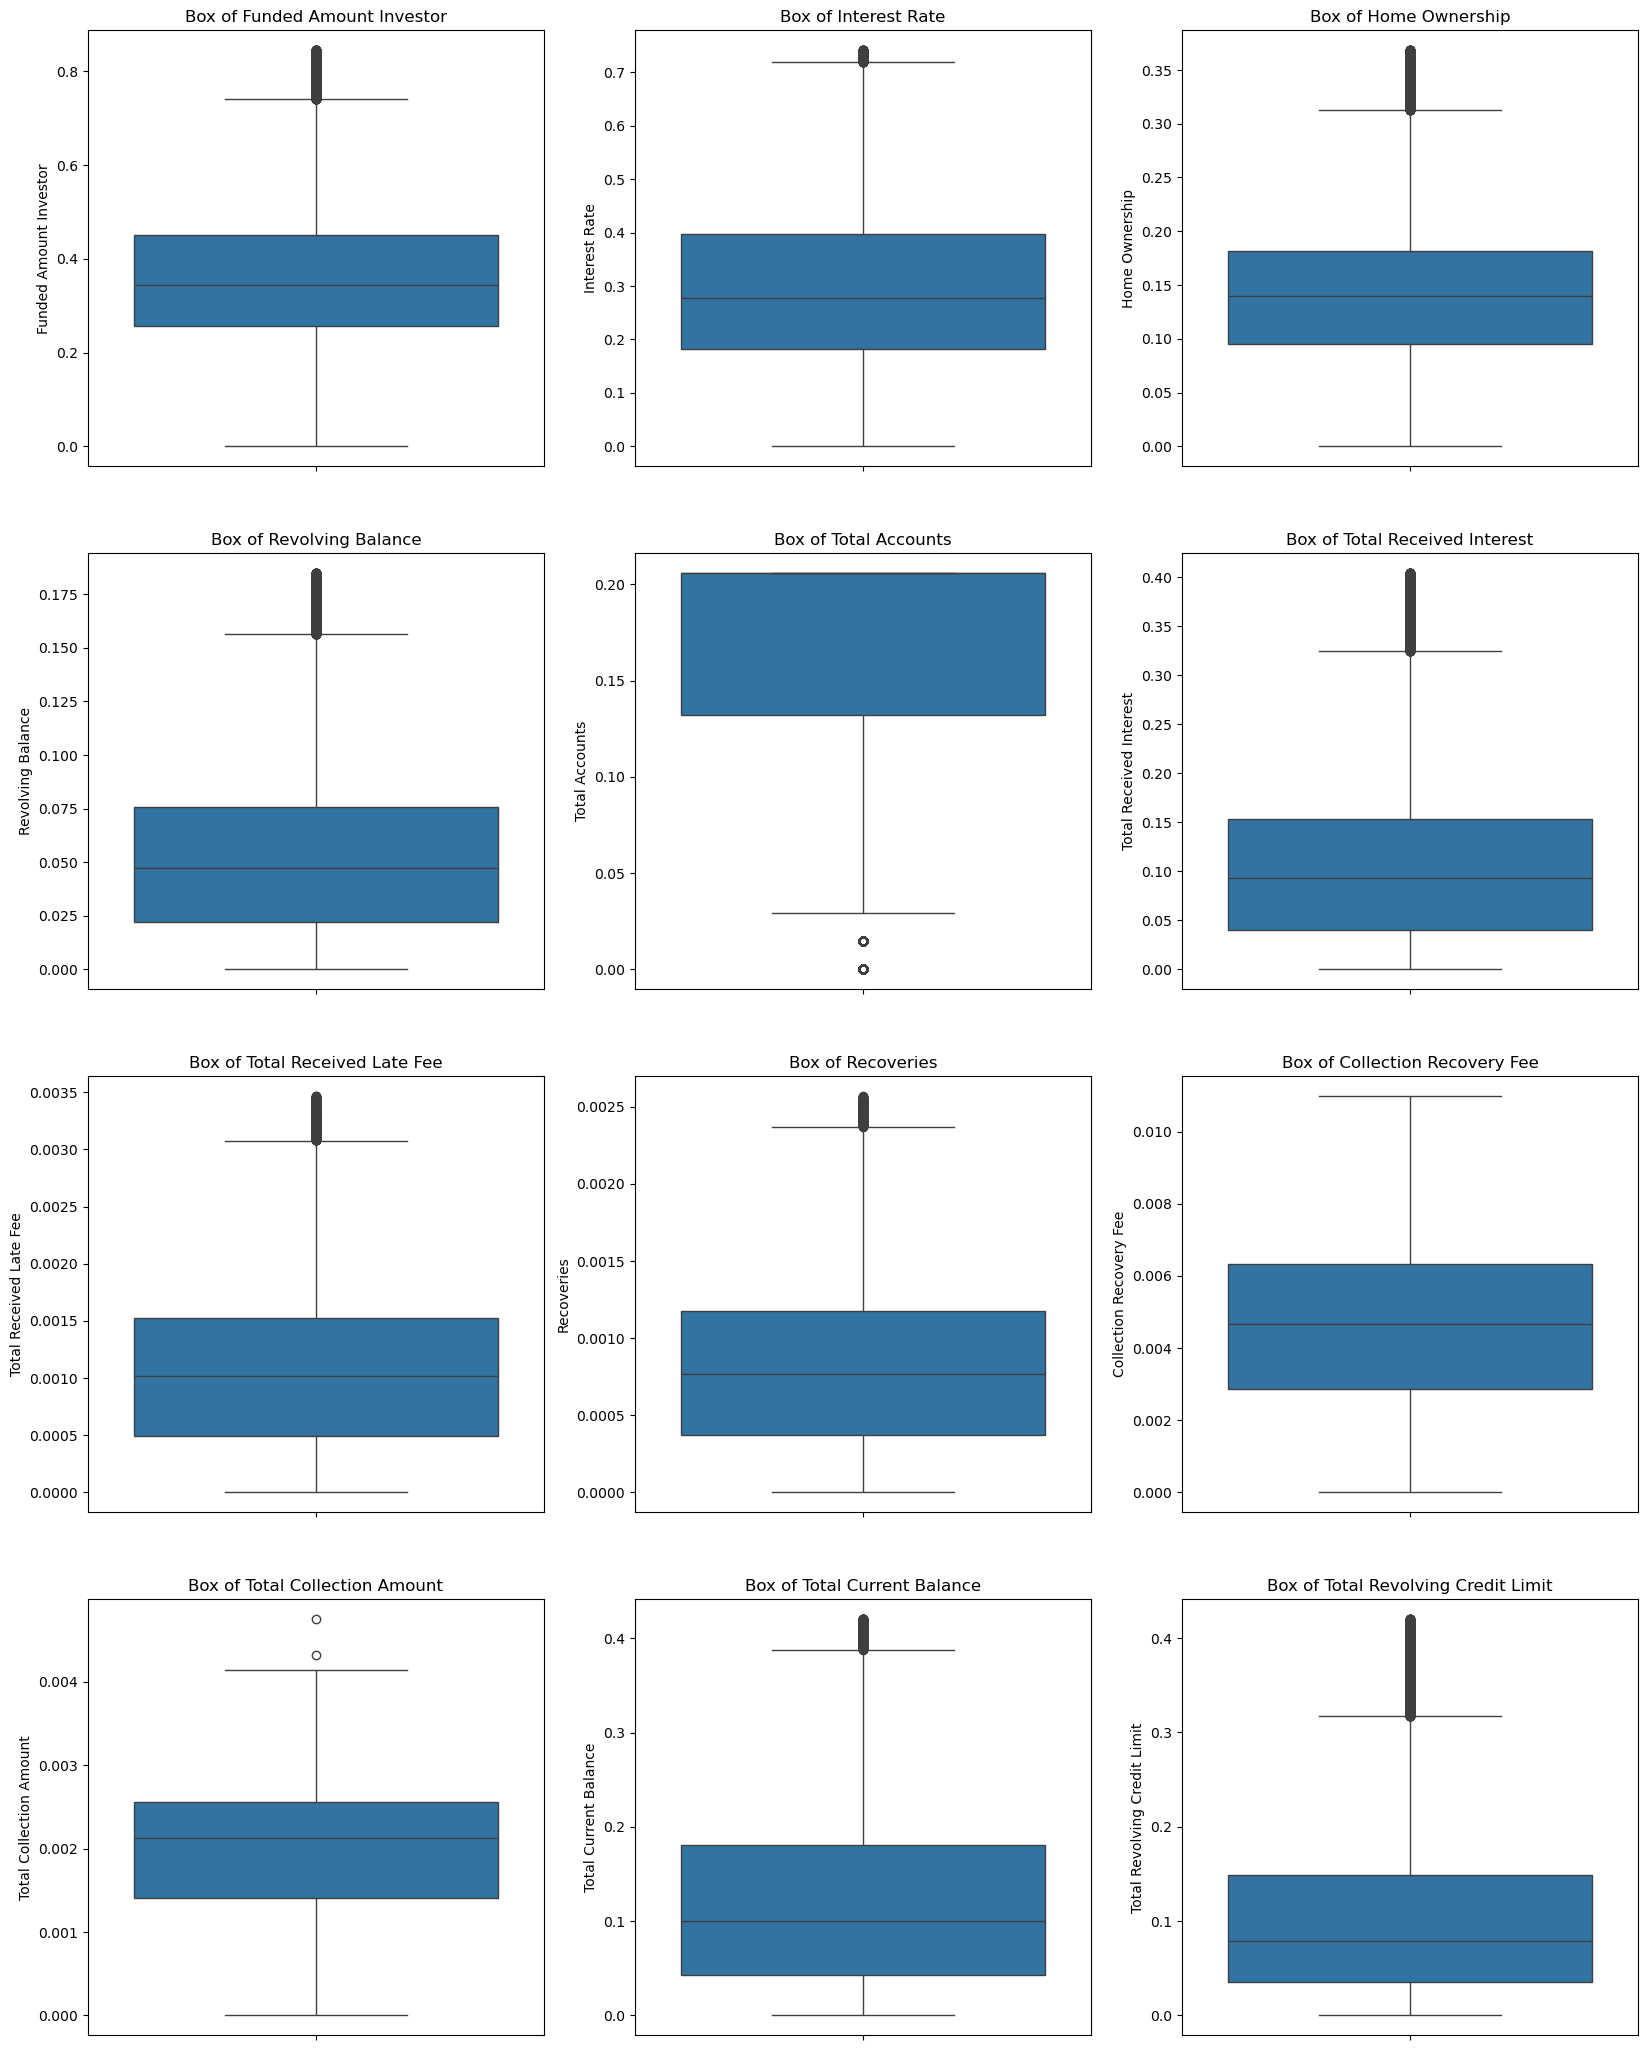

In [27]:
plt.figure(figsize=(20, 60))
plot = 1

for i in outliers:   
    plt.subplot(9, 3, plot)
    sns.boxplot(y=df_processed[i])   
    plt.title(f"Box of {i}")
    plot += 1
plt.show()

In [28]:
x=df_processed.drop(columns=["Loan Status"])
y=df_processed["Loan Status"]
y

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
67458    1.0
67459    0.0
67460    0.0
67461    0.0
67462    0.0
Name: Loan Status, Length: 67463, dtype: float64

In [29]:
x

,Employment Duration_MORTGAGE,Employment Duration_OWN,Employment Duration_RENT,Loan Purpose_Business,Loan Purpose_Car,Loan Purpose_Education,Loan Purpose_Home,Loan Purpose_Personal,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Marital Status_Widowed,Education Level_Bachelor's,Education Level_High School,Education Level_Master's,Education Level_PhD,Employment Type_Salaried,Employment Type_Self-Employed,Employment Type_Unemployed,Housing Type_Mortgaged,Housing Type_Owned,Housing Type_Rented,Loan Amount,Funded Amount,Funded Amount Investor,Interest Rate,Home Ownership,Debit to Income,Open Account,Revolving Balance,Revolving Utilities,Total Accounts,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Credit Score,Monthly Expenses,Dependents,Co-Applicant Income,Previous Defaults,Current Liabilities,Loan Tenure,Debt-to-Income Ratio,Debt-to-Income Ratio,Property Value,Years in Current Job,Savings Amount,Risk Score,Delinquency - two years,Inquires - six months,Public Record,Bankruptcy History,Loan Tenure,Verification Status,Income Stability,Collateral,Grade
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.264403,0.918699,0.330964,0.265983,0.139704,0.400709,0.314286,0.047172,0.742775,0.044118,0.204587,0.002395,0.000574,0.004757,0.001827,0.264009,0.028071,0.185792,0.223918,0.00,0.058442,1.0,0.415809,0.25,0.597618,0.597618,0.002876,0.846154,0.952253,0.216434,1.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,5.0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.076355,0.321495,0.326910,0.316414,0.064442,0.378315,0.285714,0.006944,0.776130,0.132353,0.053721,0.000849,0.000546,0.005843,0.003167,0.154651,0.099341,0.792350,0.347405,0.25,0.025041,0.0,0.563031,0.50,0.287504,0.287504,0.474724,0.846154,0.659275,0.677137,0.0,0.0,0.0,1.0,3.0,1.0,0.0,0.0,4.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.802154,0.244137,0.604649,0.330517,0.196264,0.704983,0.342857,0.015761,0.020499,0.205882,0.060055,0.001018,0.000991,0.006114,0.002010,0.075786,0.125669,0.491803,0.732709,1.00,0.484079,1.0,0.041965,0.50,0.042703,0.042703,0.253845,0.897436,0.873244,0.981327,0.0,0.0,0.0,1.0,3.0,1.0,1.0,1.0,1.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.298829,0.174783,0.494688,0.521957,0.239071,0.445864,0.142857,0.118179,0.668777,0.117647,0.019825,0.001035,0.000025,0.004495,0.002375,0.007284,0.295820,0.193078,0.448363,1.00,0.403156,1.0,0.759288,0.00,0.536726,0.536726,0.930242,0.846154,0.308019,0.399830,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,4.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.467134,0.359335,0.366690,0.443150,0.075669,0.424458,0.314286,0.013204,0.845063,0.205882,0.008709,0.001018,0.000768,0.002211,0.002132,0.106571,0.107804,0.129326,0.865460,0.50,0.779391,1.0,0.479575,0.75,0.349974,0.349974,0.319690,0.564103,0.472651,0.492227,1.0,3.0,1.0,0.0,4.0,1.0,1.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67458,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.370358,0.171664,0.355929,0.187027,0.177015,0.704149,0.314286,0.035165,0.969262,0.205882,0.138089,0.000551,0.000768,0.005186,0.002862,0.153942,0.166364,0.282332,0.114749,0.00,0.365095,1.0,0.014855,0.25,0.320855,0.320855,0.805141,0.794872,0.124971,0.646435,1.0,0.0,0.0,0.0,2.0,2.0,1.0,0.0,4.0
67459,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.215059,0.295189,0.428591,0.212790,0.129896,0.436893,0.285714,0.083270,0.155495,0.147059,0.216559,0.000636,0.000463,0.008412,0.002192,0.018759,0.038537,0.386157

In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
x_train

,Employment Duration_MORTGAGE,Employment Duration_OWN,Employment Duration_RENT,Loan Purpose_Business,Loan Purpose_Car,Loan Purpose_Education,Loan Purpose_Home,Loan Purpose_Personal,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Marital Status_Widowed,Education Level_Bachelor's,Education Level_High School,Education Level_Master's,Education Level_PhD,Employment Type_Salaried,Employment Type_Self-Employed,Employment Type_Unemployed,Housing Type_Mortgaged,Housing Type_Owned,Housing Type_Rented,Loan Amount,Funded Amount,Funded Amount Investor,Interest Rate,Home Ownership,Debit to Income,Open Account,Revolving Balance,Revolving Utilities,Total Accounts,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Credit Score,Monthly Expenses,Dependents,Co-Applicant Income,Previous Defaults,Current Liabilities,Loan Tenure,Debt-to-Income Ratio,Debt-to-Income Ratio,Property Value,Years in Current Job,Savings Amount,Risk Score,Delinquency - two years,Inquires - six months,Public Record,Bankruptcy History,Loan Tenure,Verification Status,Income Stability,Collateral,Grade
12727,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.456394,0.290305,0.620896,0.260257,0.218674,0.275075,0.342857,0.038988,0.502823,0.205882,0.222065,0.001909,0.000087,0.001373,0.002010,0.068463,0.088905,0.846995,0.046005,1.00,0.393516,0.0,0.320233,0.25,0.195009,0.195009,0.711894,0.538462,0.505038,0.249962,0.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,3.0
466,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.430942,0.929616,0.278230,0.470350,0.066315,0.981897,0.142857,0.006705,0.683254,0.000000,0.019525,0.001060,0.001441,0.003031,0.002801,0.100062,0.064281,0.163934,0.313928,0.00,0.612945,0.0,0.116386,0.75,0.193438,0.193438,0.785806,0.358974,0.548765,0.033318,0.0,0.0,0.0,0.0,4.0,0.0,1.0,0.0,4.0
49785,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.767757,0.173930,0.342739,0.220122,0.092284,0.775399,0.285714,0.088316,0.832285,0.205882,0.051144,0.000497,0.000246,0.002591,0.001157,0.173323,0.174213,0.821494,0.822508,0.00,0.048622,1.0,0.031750,0.50,0.645613,0.645613,0.009812,0.846154,0.660455,0.746447,0.0,0.0,0.0,0.0,3.0,1.0,1.0,0.0,6.0
32791,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.636586,0.275857,0.290718,0.421623,0.118617,0.705448,0.342857,0.020969,0.509539,0.205882,0.004355,0.000118,0.000056,0.007541,0.001035,0.231927,0.122996,0.626594,0.914938,0.00,0.976679,0.0,0.046545,0.75,0.409894,0.409894,0.923851,0.974359,0.155177,0.091585,1.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,5.0
795,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.426117,0.665676,0.156172,0.572872,0.139704,0.646175,0.828571,0.123960,0.884899,0.205882,0.389474,0.001742,0.001260,0.005702,0.000853,0.085067,0.099651,0.025501,0.640804,0.00,0.739390,0.0,0.977265,0.00,0.034914,0.034914,0.695321,0.538462,0.879445,0.499069,2.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.388895,0.163837,0.231692,0.341646,0.055397,0.558870,0.342857,0.065054,0.554999,0.205882,0.023912,0.001303,0.000038,0.006859,0.002741,0.183224,0.171380,0.428051,0.339720,0.50,0.200968,1.0,0.356334,1.00,0.270059,0.270059,0.140551,0.871795,0.039012,0.795464,1.0,0.0,0.0,1.0,5.0,1.0,1.0,1.0,6.0
6265,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.542959,0.297572,0.345981,0.497324,0.200479,0.673692,0.228571,0.008005,0.966532,0.058824,0.026838,0.002045,0.001030,0.002139,0.001096,0.228400,0.

In [31]:
df_processed["Loan Status"].value_counts()

Loan Status
0.0    61222
1.0     6241
Name: count, dtype: int64

In [32]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

C:\Users\Tanmay Patel\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [33]:
from collections import Counter

print("Before Apply SMOTE->>>> ",Counter(y_train))
print("After Apply SMOTE->>>> ",Counter(y_train_smote))


Before Apply SMOTE->>>>  Counter({0.0: 48947, 1.0: 5023})
After Apply SMOTE->>>>  Counter({0.0: 48947, 1.0: 48947})


In [34]:
y_train_smote

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
97889    1.0
97890    1.0
97891    1.0
97892    1.0
97893    1.0
Name: Loan Status, Length: 97894, dtype: float64

In [35]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(class_weight='balanced',max_iter=1000)
lr.fit(x_train_smote,y_train_smote) 

LogisticRegression(class_weight='balanced', max_iter=1000)

In [36]:
y_pred=lr.predict(x_test)
y_pred_prob=lr.predict_proba(x_test)

In [37]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,classification_report,f1_score
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[6081 6194]
 [ 608  610]]


In [38]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

         0.0       0.91      0.50      0.64     12275
         1.0       0.09      0.50      0.15      1218

    accuracy                           0.50     13493
   macro avg       0.50      0.50      0.40     13493
weighted avg       0.84      0.50      0.60     13493



from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

lr = LogisticRegression(
    max_iter=1000,
    solver='liblinear'   # supports l1 and l2
)

param_dist = {
    'C': loguniform(1e-4, 1e2),   # wide range
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=30,            # 20–50 is usually enough
    scoring='f1',         # IMPORTANT
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train,y_train)


print("Best Parameters:", random_search.best_params_)
print("Best CV F1 Score:", random_search.best_score_)


best_model = random_search.best_estimator_

y_pred = best_model.predict(x_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


In [42]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

# Fit model
dt.fit(x_train_smote, y_train_smote)
y_pred1=dt.predict(x_test)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

         0.0       0.91      0.88      0.90     12275
         1.0       0.10      0.14      0.12      1218

    accuracy                           0.81     13493
   macro avg       0.51      0.51      0.51     13493
weighted avg       0.84      0.81      0.83     13493



In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier()
rf.fit(x_train_smote, y_train_smote)
y_pred = rf.predict(x_test)

print("Random Forest")
print(classification_report(y_test, y_pred))


Random Forest
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95     12275
         1.0       0.08      0.00      0.00      1218

    accuracy                           0.91     13493
   macro avg       0.50      0.50      0.48     13493
weighted avg       0.84      0.91      0.87     13493



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm = SVC()

svm.fit(x_train_smote, y_train_smote)
y_pred = svm.predict(x_test)

print("SVM")
print(classification_report(y_test, y_pred))


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn = KNeighborsClassifier()

knn.fit(x_train_smote, y_train_smote)
y_pred = knn.predict(x_test)

print("KNN")
print(classification_report(y_test, y_pred))


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

nb = GaussianNB()

nb.fit(x_train_smote, y_train_smote)
y_pred = nb.predict(x_test)

print("Naive Bayes")
print(classification_report(y_test, y_pred))
